# Import all Liberies


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# P1 Load, Clean & Merge

## 1.Load Data

In [ ]:
Tickets = pd.read_csv("tickets.csv")
Teams = pd.read_csv("teams.csv")
Tickets

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5
5,6,Feb,T2,Phone,30,3
6,7,Feb,T3,Email,18,4
7,8,Feb,T4,Chat,40,2
8,9,Mar,T1,Phone,16,4
9,10,Mar,T2,Email,22,4


In [ ]:
Teams

,team_id,team,department
0,T1,AccountCare,Service
1,T2,BillingHelp,Service
2,T3,AppSupport,Technical
3,T4,DeviceHelp,Technical


# 2.CHECKING DATA TYPES

In [ ]:
Tickets.dtypes

,0
ticket_id,int64
month,object
team_id,object
channel,object
resolution_hours,int64
satisfaction,int64


# 3. DELETING DUPLICATES

In [ ]:
Tickets_new = Tickets.drop_duplicates()

In [ ]:
Tickets_new

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5
5,6,Feb,T2,Phone,30,3
6,7,Feb,T3,Email,18,4
7,8,Feb,T4,Chat,40,2
8,9,Mar,T1,Phone,16,4
9,10,Mar,T2,Email,22,4


In [ ]:
print(f'rows without deleting duplicates :{len(Tickets)}')
print(f'rows with deleting duplicates :{len(Tickets_new)}')

rows without deleting duplicates :13
rows with deleting duplicates :12


# 4.MARGING

In [ ]:
marged = pd.merge(Tickets_new, Teams, on='team_id', how='left')
marged

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department
0,1,Jan,T1,Email,12,4,AccountCare,Service
1,2,Jan,T2,Chat,28,3,BillingHelp,Service
2,3,Jan,T3,Phone,36,2,AppSupport,Technical
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical
4,5,Feb,T1,Chat,8,5,AccountCare,Service
5,6,Feb,T2,Phone,30,3,BillingHelp,Service
6,7,Feb,T3,Email,18,4,AppSupport,Technical
7,8,Feb,T4,Chat,40,2,DeviceHelp,Technical
8,9,Mar,T1,Phone,16,4,AccountCare,Service
9,10,Mar,T2,Email,22,4,BillingHelp,Service


# P2 - Derived Field & Department Analysis

#Calculate breach_flag

In [ ]:
marged['breach_flag'] = (marged['resolution_hours'] > 24).astype(int)
marged

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department,breach_flag
0,1,Jan,T1,Email,12,4,AccountCare,Service,0
1,2,Jan,T2,Chat,28,3,BillingHelp,Service,1
2,3,Jan,T3,Phone,36,2,AppSupport,Technical,1
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical,0
4,5,Feb,T1,Chat,8,5,AccountCare,Service,0
5,6,Feb,T2,Phone,30,3,BillingHelp,Service,1
6,7,Feb,T3,Email,18,4,AppSupport,Technical,0
7,8,Feb,T4,Chat,40,2,DeviceHelp,Technical,1
8,9,Mar,T1,Phone,16,4,AccountCare,Service,0
9,10,Mar,T2,Email,22,4,BillingHelp,Service,0


### Department-level SLA Breach Analysis

In [ ]:
department_summary = marged.groupby('department').agg(
    total_tickets=('ticket_id', 'count'),
    breached_tickets=('breach_flag', 'sum')
).reset_index()

department_summary['sla_breach_rate_percent'] = (department_summary['breached_tickets'] / department_summary['total_tickets']) * 100

display(department_summary)

,department,total_tickets,breached_tickets,sla_breach_rate_percent
0,Service,6,2,33.333333
1,Technical,6,3,50.000000


### Team-level SLA Breach Analysis

In [ ]:
team_summary = marged.groupby('team').agg(
    total_tickets=('ticket_id', 'count'),   #count total tickets
    breached_tickets=('breach_flag', 'sum')  #sum of breach_flag
).reset_index()

team_summary['sla_breach_rate_percent'] = (team_summary['breached_tickets'] / team_summary['total_tickets']) * 100

highest_breach_team = team_summary.loc[team_summary['sla_breach_rate_percent'].idxmax()]

print("Team with the highest breach rate:")

print(f"Team: {highest_breach_team['team']}")

print(f"Breached Tickets (Numerator): {highest_breach_team['breached_tickets']}")
print(f"Total Tickets (Denominator): {highest_breach_team['total_tickets']}")
print(f"SLA Breach Rate: {highest_breach_team['sla_breach_rate_percent']:.2f}%")

Team with the highest breach rate:
Team: AppSupport
Breached Tickets (Numerator): 2
Total Tickets (Denominator): 3
SLA Breach Rate: 66.67%


#P3 — Bar Chart

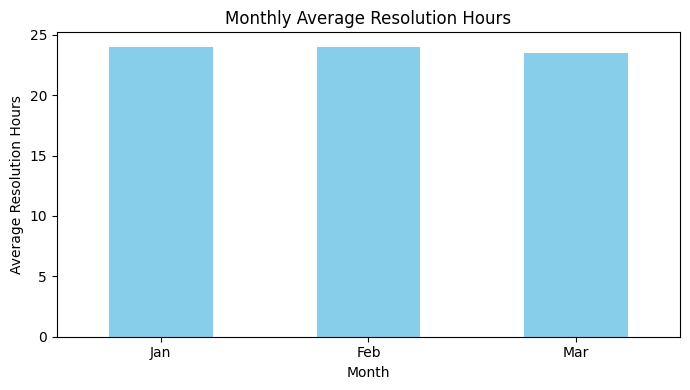

In [ ]:
monthly_avg_resolution = marged.groupby('month')['resolution_hours'].mean().reindex(['Jan', 'Feb', 'Mar'])

plt.figure(figsize=(7, 4))

monthly_avg_resolution.plot(kind='bar', color='skyblue')
plt.title('Monthly Average Resolution Hours')
plt.xlabel('Month')
plt.ylabel('Average Resolution Hours')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()